Ensemble Learning Assignment

1) Can we use Bagging for regression problems?

ans : Yes. Bagging works for both classification and regression.

For regression, predictions from multiple models are averaged.

2) Difference between multiple model training and single model training

ans: Single model training uses one model and may have higher variance.
      Multiple model training (ensemble) combines several models to improve performance and reduce
      variance.

3) Concept of feature randomness in Random Forest

ans: At each split, a random subset of features is selected.
    The best split is chosen only from that subset to reduce correlation between trees.

4) What is OOB (Out-of-Bag) Score?

ans : OOB samples are data points not selected during bootstrap sampling.
They are used to estimate model performance like built-in cross-validation.

5) How to measure feature importance in Random Forest?

- Mean Decrease in Impurity
- Permutation Importance

6) Working principle of a Bagging Classifier
- Create bootstrap samples
- Train a classifier on each
- Combine predictions using majority voting

7) How to evaluate a Bagging Classifier’s performance?

ans : Accuracy, Precision, Recall, F1-score, ROC-AUC, OOB score, Cross-validation.

8) How does a Bagging Regressor work?

- Create bootstrap datasets
- Train a regressor on each
- Final prediction is the average of predictions

9) Main advantage of ensemble techniques

ans: Higher accuracy, reduced variance, better generalization, robustness.

10) Main challenge of ensemble methods

Ans: Higher computational cost, less interpretability, more memory usage.

11) Key idea behind ensemble techniques

Ans: Combine multiple weak learners to create a strong learner.

12) What is a Random Forest Classifier?

Ans: An ensemble of decision trees using bootstrap sampling and feature randomness.
Final prediction is made by majority voting.

13) Main types of ensemble techniques

  1. Bagging,
  2. Boosting,
  3. Stacking.

14) What is ensemble learning?

ans: Combining multiple models to improve predictive performance.

15) When should we avoid ensemble methods?

ans: Small datasets, need high interpretability, limited resources, real-time systems.

16) How does Bagging reduce overfitting?

ans : By training on different bootstrap samples and averaging predictions to reduce variance.

17) Why is Random Forest better than a single Decision Tree?

ans: Lower variance, less overfitting, more stable predictions.

18) Role of bootstrap sampling in Bagging

ans: Creates diverse training subsets and enables OOB validation.

19) Real-world applications

ans: 1. Fraud detection,
    2. medical diagnosis,
    3. credit scoring,
    4. recommendation systems, spam detection.

20) Difference between Bagging and Boosting

ans:
    - Bagging: Independent models, reduces variance.
    - Boosting: Sequential models, reduces bias.

Prectical


In [28]:
# Import necessary libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score

# Load the iris dataset
data = load_iris()
X = data.data
y = data.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create a BaggingClassifier using the default base estimator (DecisionTreeClassifier)
bagging_classifier = BaggingClassifier(DecisionTreeClassifier(random_state=42),
                                      n_estimators=50, random_state=42)

# Fit the model on the training data
bagging_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = bagging_classifier.predict(X_test)

# Calculate the accuracy
accuracy = accuracy_score(y_test, y_pred)

# Print the accuracy of the model
print(f'Model Accuracy: {accuracy * 100:.2f}%')

Model Accuracy: 100.00%


In [29]:
#22. Train a Bagging Regressor using Decision Trees and evaluate using Mean Squared Error (MSE)
# Import necessary libraries
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.metrics import mean_squared_error

# Load the California housing dataset
california = fetch_california_housing()
X = california.data
y = california.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

# Create a DecisionTreeRegressor model
dt_regressor = DecisionTreeRegressor(random_state=1)

# Create a BaggingRegressor with the DecisionTree as base estimator
# bagging_regressor = BaggingRegressor(base_estimator=dt_regressor, n_estimators=50, random_state=42)
bagging_regressor = BaggingRegressor(estimator=dt_regressor,n_estimators=50, random_state=1)

# Fit the model on the training data
bagging_regressor.fit(X_train, y_train)

# Make predictions on the test set
y_pred = bagging_regressor.predict(X_test)

# Calculate the Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)

# Print the MSE of the model
print(f'Mean Squared Error: {mse:.2f}')

Mean Squared Error: 0.26


In [30]:
#23. Train a Random Forest Classifier on the Breast Cancer dataset and print feature importance scores
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=1)

rf_Classifier = RandomForestClassifier(n_estimators=100, random_state=1)

rf_Classifier.fit(X_train ,y_train)

y_pred = rf_Classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")

importances = rf_Classifier.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": data.feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance Scores:")
print(feature_importance_df)



Model Accuracy: 0.95

Feature Importance Scores:
                    Feature  Importance
22          worst perimeter    0.141142
27     worst concave points    0.125184
23               worst area    0.115155
20             worst radius    0.089507
7       mean concave points    0.081823
2            mean perimeter    0.073608
6            mean concavity    0.068204
0               mean radius    0.058146
3                 mean area    0.047602
13               area error    0.031727
10             radius error    0.023007
26          worst concavity    0.019958
21            worst texture    0.019246
1              mean texture    0.015433
25        worst compactness    0.014217
28           worst symmetry    0.010095
24         worst smoothness    0.008627
29  worst fractal dimension    0.006844
12          perimeter error    0.006349
17     concave points error    0.005690
5          mean compactness    0.005603
4           mean smoothness    0.005513
19  fractal dimension error    

In [31]:
#24. Train a Random Forest Regressor and compare its performance with a single Decision Tree
# Import necessary libraries
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
data = fetch_california_housing()
X = data.data
y = data.target

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# -----------------------------
# 1️⃣ Decision Tree Regressor
# -----------------------------
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_mse = mean_squared_error(y_test, dt_pred)
dt_r2 = r2_score(y_test, dt_pred)

# -----------------------------
# 2️⃣ Random Forest Regressor
# -----------------------------
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

# -----------------------------
# Print Results
# -----------------------------
print("Decision Tree Performance:")
print(f"MSE: {dt_mse:.4f}")
print(f"R2 Score: {dt_r2:.4f}")

print("\nRandom Forest Performance:")
print(f"MSE: {rf_mse:.4f}")
print(f"R2 Score: {rf_r2:.4f}")

Decision Tree Performance:
MSE: 0.5280
R2 Score: 0.5977

Random Forest Performance:
MSE: 0.2565
R2 Score: 0.8046


In [32]:
#25. Compute the Out-of-Bag (OOB) Score for a Random Forest Classifier
# Import necessary libraries
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split dataset (optional for comparison with test accuracy)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Create Random Forest with OOB enabled
rf_model = RandomForestClassifier(
    n_estimators=200,
    oob_score=True,       # 🔹 Enable OOB scoring
    bootstrap=True,       # Must be True for OOB
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

# OOB Score
print(f"OOB Score: {rf_model.oob_score_:.4f}")

# Optional: Compare with Test Accuracy
y_pred = rf_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")

OOB Score: 0.9548
Test Accuracy: 0.9708


In [33]:
# 26. Train a Bagging Classifier using SVM as a base estimator and print accuracy
# Import necessary libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Create SVM base estimator
svm = SVC(kernel='rbf', probability=True, random_state=42)

# Create Bagging Classifier with SVM as base estimator
bagging_model = BaggingClassifier(
    estimator=svm,          # Use 'estimator' (new sklearn versions)
    n_estimators=10,
    bootstrap=True,
    random_state=42
)

# Train the model
bagging_model.fit(X_train, y_train)

# Make predictions
y_pred = bagging_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.9474


In [34]:
# 27. Train a Random Forest Classifier with different numbers of trees and compare accuracy2
# Import necessary libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Different numbers of trees to test
tree_counts = [10, 50, 100, 200]

print("Random Forest Performance with Different Numbers of Trees:\n")

for n in tree_counts:
    rf_model = RandomForestClassifier(
        n_estimators=n,
        random_state=42
    )

    rf_model.fit(X_train, y_train)
    y_pred = rf_model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    print(f"Number of Trees: {n} -> Accuracy: {accuracy:.4f}")

Random Forest Performance with Different Numbers of Trees:

Number of Trees: 10 -> Accuracy: 0.9649
Number of Trees: 50 -> Accuracy: 0.9708
Number of Trees: 100 -> Accuracy: 0.9708
Number of Trees: 200 -> Accuracy: 0.9708


In [35]:
# 28. Train a Bagging Classifier using Logistic Regression as a base estimator and print AUC score2
# Import necessary libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Create Logistic Regression base estimator
logreg = LogisticRegression(max_iter=1000, random_state=42)

# Create Bagging Classifier with Logistic Regression as base estimator
bagging_model = BaggingClassifier(
    estimator=logreg,      # use 'estimator' in sklearn ≥1.2
    n_estimators=50,
    bootstrap=True,
    random_state=42
)

# Train the model
bagging_model.fit(X_train, y_train)

# Get predicted probabilities for positive class
y_prob = bagging_model.predict_proba(X_test)[:, 1]

# Calculate AUC score
auc_score = roc_auc_score(y_test, y_prob)
print(f"AUC Score: {auc_score:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

AUC Score: 0.9982


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [36]:
# 29. Train a Random Forest Regressor and analyze feature importance scores2
# Import necessary libraries
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

# Load California Housing dataset
california = fetch_california_housing()
X = california.data
y = california.target
feature_names = california.feature_names

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Create Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

# Get feature importance scores
importances = rf_model.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Print feature importance scores
print("Feature Importance Scores:")
print(feature_importance_df)

Feature Importance Scores:
      Feature  Importance
0      MedInc    0.526011
5    AveOccup    0.138220
7   Longitude    0.086124
6    Latitude    0.086086
1    HouseAge    0.054654
2    AveRooms    0.047188
4  Population    0.031722
3   AveBedrms    0.029995


In [37]:
# 30 Train an ensemble model using both Bagging and Random Forest and compare accuracy.
# Import necessary libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Load the Breast Cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# -----------------------------
# 1️⃣ Bagging Classifier
# -----------------------------
# Use Decision Tree as base estimator
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=50,
    random_state=42
)

# Train the Bagging model
bagging_model.fit(X_train, y_train)

# Predict and calculate accuracy
y_pred_bagging = bagging_model.predict(X_test)
accuracy_bagging = accuracy_score(y_test, y_pred_bagging)

# -----------------------------
# 2️⃣ Random Forest Classifier
# -----------------------------
rf_model = RandomForestClassifier(
    n_estimators=50,
    random_state=42
)

# Train the Random Forest model
rf_model.fit(X_train, y_train)

# Predict and calculate accuracy
y_pred_rf = rf_model.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

# -----------------------------
# Compare Accuracy
# -----------------------------
print("Ensemble Model Comparison:\n")
print(f"Bagging Classifier Accuracy: {accuracy_bagging:.4f}")
print(f"Random Forest Classifier Accuracy: {accuracy_rf:.4f}")

Ensemble Model Comparison:

Bagging Classifier Accuracy: 0.9591
Random Forest Classifier Accuracy: 0.9708


In [38]:
# 31. Train a Random Forest Classifier and tune hyperparameters using GridSearchCV=

# Import necessary libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Create a Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)

# Define hyperparameter grid to tune
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

# Create GridSearchCV object
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,             # 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1         # Use all available cores
)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Best hyperparameters
print("Best Hyperparameters:")
print(grid_search.best_params_)

# Predict on the test set using the best model
best_rf_model = grid_search.best_estimator_
y_pred = best_rf_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest Set Accuracy: {accuracy:.4f}")

Best Hyperparameters:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}

Test Set Accuracy: 0.9708


In [40]:
# 32. Train a Bagging Regressor with different numbers of base estimators and compare performance=
# Import necessary libraries
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
california = fetch_california_housing()
X = california.data
y = california.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Different numbers of base estimators to try
n_estimators_list = [5, 10, 20, 50, 100]

print("Bagging Regressor Performance with Different Numbers of Base Estimators:\n")

for n in n_estimators_list:
    # Create Bagging Regressor with Decision Tree as base estimator
    bagging_model = BaggingRegressor(
        estimator=DecisionTreeRegressor(random_state=42),
        n_estimators=n,
        random_state=42
    )

    # Train the model
    bagging_model.fit(X_train, y_train)

    # Predict on the test set
    y_pred = bagging_model.predict(X_test)

    # Evaluate performance
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"Number of Base Estimators: {n} -> MSE: {mse:.4f}, R2: {r2:.4f}")

Bagging Regressor Performance with Different Numbers of Base Estimators:

Number of Base Estimators: 5 -> MSE: 0.3168, R2: 0.7586
Number of Base Estimators: 10 -> MSE: 0.2862, R2: 0.7819
Number of Base Estimators: 20 -> MSE: 0.2693, R2: 0.7948
Number of Base Estimators: 50 -> MSE: 0.2579, R2: 0.8035
Number of Base Estimators: 100 -> MSE: 0.2568, R2: 0.8043


In [41]:
# 33. Train a Random Forest Classifier and analyze misclassified samples=
# Import necessary libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import pandas as pd

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict on test set
y_pred = rf_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Set Accuracy: {accuracy:.4f}\n")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm, "\n")

# Analyze misclassified samples
misclassified_idx = (y_test != y_pred)
X_misclassified = X_test[misclassified_idx]
y_misclassified_true = y_test[misclassified_idx]
y_misclassified_pred = y_pred[misclassified_idx]

# Create DataFrame for better visualization
misclassified_df = pd.DataFrame(X_misclassified, columns=feature_names)
misclassified_df['True_Label'] = y_misclassified_true
misclassified_df['Predicted_Label'] = y_misclassified_pred

print("Misclassified Samples:")
print(misclassified_df)

Test Set Accuracy: 0.9708

Confusion Matrix:
[[ 59   4]
 [  1 107]] 

Misclassified Samples:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        13.34         15.86           86.49      520.0          0.10780   
1        13.80         15.79           90.43      584.1          0.10070   
2        13.96         17.05           91.43      602.4          0.10960   
3        14.48         21.46           94.25      648.2          0.09444   
4        15.13         29.81           96.71      719.5          0.08320   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.15350         0.11690              0.06987         0.1942   
1           0.12800         0.07789              0.05069         0.1662   
2           0.12790         0.09789              0.05246         0.1908   
3           0.09947         0.12040              0.04938         0.2075   
4           0.04605         0.04686              0.02739         0.1852   


In [42]:
# 34. Train a Bagging Classifier and compare its performance with a single Decision Tree Classifier=
# Import necessary libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# -----------------------------
# 1️⃣ Single Decision Tree Classifier
# -----------------------------
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt)

# -----------------------------
# 2️⃣ Bagging Classifier with Decision Tree as base estimator
# -----------------------------
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=50,
    random_state=42
)
bagging_model.fit(X_train, y_train)
y_pred_bagging = bagging_model.predict(X_test)
accuracy_bagging = accuracy_score(y_test, y_pred_bagging)

# -----------------------------
# Compare Performance
# -----------------------------
print("Performance Comparison:")
print(f"Single Decision Tree Accuracy: {accuracy_dt:.4f}")
print(f"Bagging Classifier Accuracy: {accuracy_bagging:.4f}")

Performance Comparison:
Single Decision Tree Accuracy: 0.9415
Bagging Classifier Accuracy: 0.9591


Test Accuracy: 0.9708


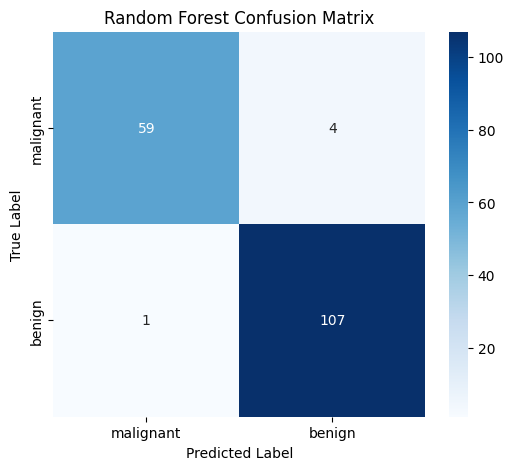

In [43]:
# 35. Train a Random Forest Classifier and visualize the confusion matrix=
# Import necessary libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target
class_names = data.target_names

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict on the test set
y_pred = rf_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize confusion matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Random Forest Confusion Matrix')
plt.show()

In [44]:
# 36. Train a Stacking Classifier using Decision Trees, SVM, and Logistic Regression, and compare accuracy=
# Import necessary libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# -----------------------------
# Define Base Learners
# -----------------------------
base_learners = [
    ('decision_tree', DecisionTreeClassifier(random_state=42)),
    ('svm', SVC(kernel='rbf', probability=True, random_state=42)),
    ('logreg', LogisticRegression(max_iter=1000, random_state=42))
]

# Define the meta-learner (final estimator)
meta_learner = LogisticRegression(max_iter=1000, random_state=42)

# -----------------------------
# Create Stacking Classifier
# -----------------------------
stacking_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=5
)
stacking_model.fit(X_train, y_train)

y_pred_stack = stacking_model.predict(X_test)
accuracy_stack = accuracy_score(y_test, y_pred_stack)
print(f"Stacking Classifier Accuracy: {accuracy_stack:.4f}")

# -----------------------------
# Compare with individual base learners
# -----------------------------
for name, model in base_learners:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {acc:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Stacking Classifier Accuracy: 0.9708
decision_tree Accuracy: 0.9415
svm Accuracy: 0.9357
logreg Accuracy: 0.9708


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [45]:
# 37. Train a Random Forest Classifier and print the top 5 most important features=
# Import necessary libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Get feature importances
importances = rf_model.feature_importances_

# Create DataFrame for feature importances
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Print top 5 most important features
top_5_features = feature_importance_df.head(5)
print("Top 5 Most Important Features:")
print(top_5_features)

Top 5 Most Important Features:
                 Feature  Importance
7    mean concave points    0.141934
27  worst concave points    0.127136
23            worst area    0.118217
6         mean concavity    0.080557
20          worst radius    0.077975


In [46]:
# 38. Train a Bagging Classifier and evaluate performance using Precision, Recall, and F1-score=
# Import necessary libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Create Bagging Classifier with Decision Tree as base estimator
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=50,
    random_state=42
)

# Train the model
bagging_model.fit(X_train, y_train)

# Make predictions
y_pred = bagging_model.predict(X_test)

# Evaluate performance
report = classification_report(y_test, y_pred, target_names=data.target_names)
print("Bagging Classifier Performance:\n")
print(report)

Bagging Classifier Performance:

              precision    recall  f1-score   support

   malignant       0.95      0.94      0.94        63
      benign       0.96      0.97      0.97       108

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171



max_depth=None -> Accuracy=0.9708
max_depth=2 -> Accuracy=0.9532
max_depth=4 -> Accuracy=0.9708
max_depth=6 -> Accuracy=0.9649
max_depth=8 -> Accuracy=0.9708
max_depth=10 -> Accuracy=0.9708
max_depth=15 -> Accuracy=0.9708


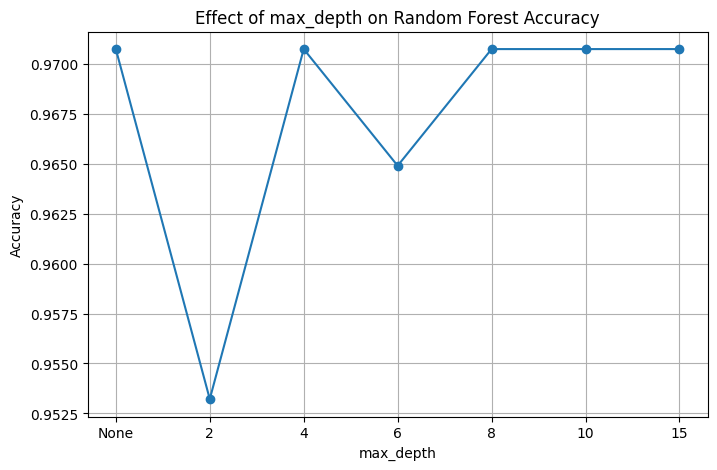

In [47]:
# 39. Train a Random Forest Classifier and analyze the effect of max_depth on accuracy=
# Import necessary libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Different max_depth values to test
max_depth_values = [None, 2, 4, 6, 8, 10, 15]

# Store accuracies
accuracies = []

# Train Random Forest for each max_depth
for depth in max_depth_values:
    rf_model = RandomForestClassifier(
        n_estimators=100,
        max_depth=depth,
        random_state=42
    )
    rf_model.fit(X_train, y_train)
    y_pred = rf_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"max_depth={depth} -> Accuracy={acc:.4f}")

# Plot accuracy vs max_depth
plt.figure(figsize=(8, 5))
plt.plot([str(d) for d in max_depth_values], accuracies, marker='o')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Effect of max_depth on Random Forest Accuracy')
plt.grid(True)
plt.show()

In [51]:
# 40 Train a Bagging Regressor using different base estimators (DecisionTree and KNeighbors) and compare performance=
# Import necessary libraries
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load California Housing dataset
california = fetch_california_housing()
X = california.data
y = california.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# -----------------------------
# 1️⃣ Bagging with Decision Tree Regressor
# -----------------------------
bagging_dt = BaggingRegressor(
    estimator=DecisionTreeRegressor(random_state=42),
    n_estimators=50,
    random_state=42
)
bagging_dt.fit(X_train, y_train)
y_pred_dt = bagging_dt.predict(X_test)
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

# -----------------------------
# 2️⃣ Bagging with K-Nearest Neighbors Regressor
# -----------------------------
bagging_knn = BaggingRegressor(
    estimator=KNeighborsRegressor(n_neighbors=5),
    n_estimators=50,
    random_state=42
)
bagging_knn.fit(X_train, y_train)
y_pred_knn = bagging_knn.predict(X_test)
mse_knn = mean_squared_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)

# -----------------------------
# Compare Performance
# -----------------------------
print("Bagging Regressor Performance Comparison:\n")
print(f"Decision Tree Base Estimator -> MSE: {mse_dt:.4f}, R²: {r2_dt:.4f}")
print(f"K-Nearest Neighbors Base Estimator -> MSE: {mse_knn:.4f}, R²: {r2_knn:.4f}")

Bagging Regressor Performance Comparison:

Decision Tree Base Estimator -> MSE: 0.2579, R²: 0.8035
K-Nearest Neighbors Base Estimator -> MSE: 1.1021, R²: 0.1603


ROC-AUC Score: 0.9968


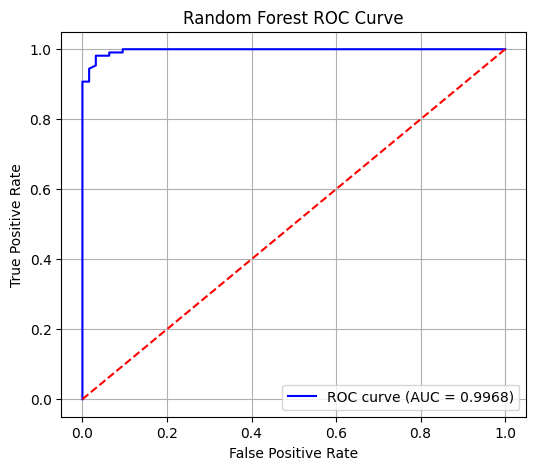

In [52]:
# 41. Train a Random Forest Classifier and evaluate its performance using ROC-AUC Score=
# Import necessary libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict probabilities for the positive class
y_prob = rf_model.predict_proba(X_test)[:, 1]

# Calculate ROC-AUC score
roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Optional: Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0,1], [0,1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

In [53]:
# 42. Train a Bagging Classifier and evaluate its performance using cross-validatio.
# Import necessary libraries
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Create Bagging Classifier with Decision Tree as base estimator
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=50,
    random_state=42
)

# Perform 5-fold cross-validation
cv_scores = cross_val_score(bagging_model, X, y, cv=5, scoring='accuracy')

# Print results
print("Cross-Validation Accuracy Scores:", cv_scores)
print(f"Mean CV Accuracy: {np.mean(cv_scores):.4f}")
print(f"Standard Deviation: {np.std(cv_scores):.4f}")

Cross-Validation Accuracy Scores: [0.9122807  0.92105263 0.98245614 0.95614035 1.        ]
Mean CV Accuracy: 0.9544
Standard Deviation: 0.0339


Average Precision Score: 0.9981


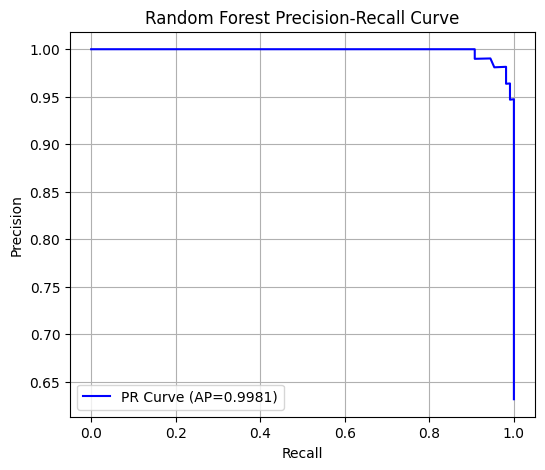

In [54]:
# 43. Train a Random Forest Classifier and plot the Precision-Recall curv
# Import necessary libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict probabilities for positive class
y_prob = rf_model.predict_proba(X_test)[:, 1]

# Compute Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# Compute average precision score
avg_precision = average_precision_score(y_test, y_prob)
print(f"Average Precision Score: {avg_precision:.4f}")

# Plot Precision-Recall curve
plt.figure(figsize=(6,5))
plt.plot(recall, precision, color='blue', label=f'PR Curve (AP={avg_precision:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Random Forest Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

In [55]:
# 44. Train a Stacking Classifier with Random Forest and Logistic Regression and compare accuracy=
# Import necessary libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# -----------------------------
# Define base learners
# -----------------------------
base_learners = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('logreg', LogisticRegression(max_iter=1000, random_state=42))
]

# Meta-learner (final estimator)
meta_learner = LogisticRegression(max_iter=1000, random_state=42)

# -----------------------------
# Create Stacking Classifier
# -----------------------------
stacking_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=5
)

# Train Stacking model
stacking_model.fit(X_train, y_train)

# Predict and evaluate stacking model
y_pred_stack = stacking_model.predict(X_test)
accuracy_stack = accuracy_score(y_test, y_pred_stack)
print(f"Stacking Classifier Accuracy: {accuracy_stack:.4f}")

# -----------------------------
# Compare with individual base learners
# -----------------------------
for name, model in base_learners:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {acc:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Stacking Classifier Accuracy: 0.9708
rf Accuracy: 0.9708
logreg Accuracy: 0.9708


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [50]:
# 45. Train a Bagging Regressor with different levels of bootstrap samples and compare performance.
# Import necessary libraries
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load California Housing dataset
california = fetch_california_housing()
X = california.data
y = california.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Different levels of bootstrap samples to test
bootstrap_samples = [0.5, 0.7, 1.0]

print("Bagging Regressor Performance with Different Bootstrap Sample Sizes:\n")

for sample_size in bootstrap_samples:
    # Create Bagging Regressor
    bagging_model = BaggingRegressor(
        estimator=DecisionTreeRegressor(random_state=42),
        n_estimators=50,
        max_samples=sample_size,  # fraction of samples for each base estimator
        random_state=42
    )

    # Train model
    bagging_model.fit(X_train, y_train)

    # Predict on test set
    y_pred = bagging_model.predict(X_test)

    # Evaluate performance
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"Bootstrap Sample Fraction: {sample_size} -> MSE: {mse:.4f}, R²: {r2:.4f}")

Bagging Regressor Performance with Different Bootstrap Sample Sizes:

Bootstrap Sample Fraction: 0.5 -> MSE: 0.2633, R²: 0.7994
Bootstrap Sample Fraction: 0.7 -> MSE: 0.2621, R²: 0.8003
Bootstrap Sample Fraction: 1.0 -> MSE: 0.2579, R²: 0.8035
